# **Question 3**

Design and implement a method to determine whether to shapes are similar using geometric moments Compute normalised central moments and hue moments.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

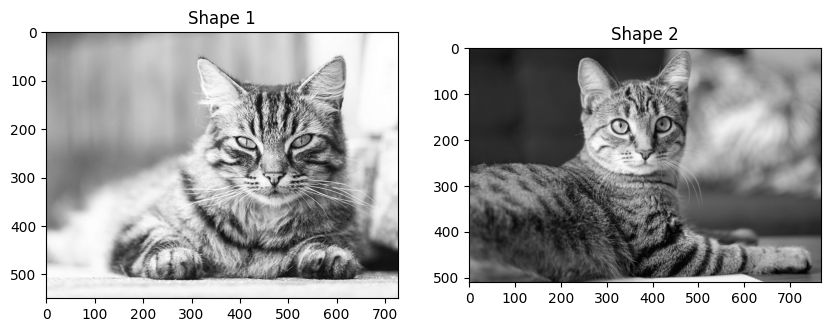

In [4]:
img1 = cv2.imread("image1.jpg", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("image2.jpg", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Shape 1")
plt.imshow(img1, cmap='gray')

plt.subplot(1,2,2)
plt.title("Shape 2")
plt.imshow(img2, cmap='gray')

plt.show()


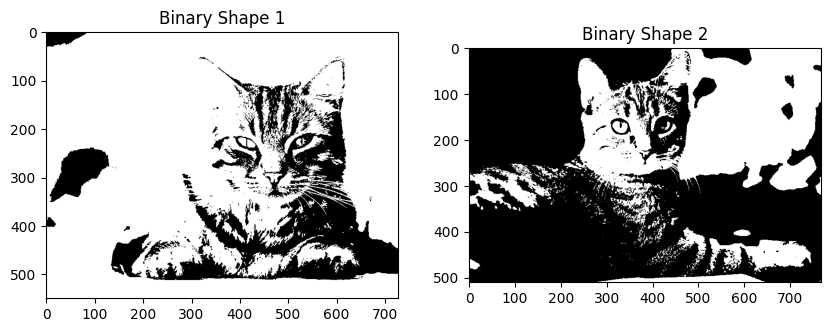

In [5]:
_, bin1 = cv2.threshold(img1, 127, 255, cv2.THRESH_BINARY)
_, bin2 = cv2.threshold(img2, 127, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Binary Shape 1")
plt.imshow(bin1, cmap='gray')

plt.subplot(1,2,2)
plt.title("Binary Shape 2")
plt.imshow(bin2, cmap='gray')

plt.show()


In [6]:
moments1 = cv2.moments(bin1)
moments2 = cv2.moments(bin2)

print("Geometric Moments for Shape 1:\n")
for key, value in moments1.items():
    print(f"{key}: {value}")

print("\n---------------------------------\n")

print("Geometric Moments for Shape 2:\n")
for key, value in moments2.items():
    print(f"{key}: {value}")


Geometric Moments for Shape 1:

m00: 80982900.0
m10: 27846786675.0
m01: 20679507030.0
m20: 13203541319805.0
m11: 6879091245315.0
m02: 7392732191670.0
m30: 7193636744928195.0
m21: 3215867172073005.0
m12: 2427001452571155.0
m03: 3035900098641540.0
mu20: 3628142956410.2876
mu11: -231765748057.34018
mu02: 2112086388619.9802
mu30: 158318864804366.06
mu21: 3647520092723.0
mu12: 3301715289460.0
mu03: 69448317198599.8
nu20: 0.0005532198329865288
nu11: -3.5339679271937765e-05
nu02: 0.0003220512789059276
nu30: 2.682559448297626e-06
nu21: 6.180368650116596e-08
nu12: 5.5944359860552744e-08
nu03: 1.1767343057928287e-06

---------------------------------

Geometric Moments for Shape 2:

m00: 35859120.0
m10: 17904069945.0
m01: 7301788575.0
m20: 10084604957865.0
m11: 3512276511135.0
m02: 2061336585675.0
m30: 6047699157340695.0
m21: 1945169709995175.0
m12: 992991784743075.0
m03: 698236381676895.0
mu20: 1145296893544.0598
mu11: -133427381498.22366
mu02: 574514923737.9384
mu30: -131103443306417.06
mu21: 

In [7]:
print("\nNormalized Central Moments (Shape 1):\n")
for key in moments1:
    if "nu" in key:
        print(f"{key}: {moments1[key]}")

print("\n-----------------------------\n")

print("Normalized Central Moments (Shape 2):\n")
for key in moments2:
    if "nu" in key:
        print(f"{key}: {moments2[key]}")



Normalized Central Moments (Shape 1):

nu20: 0.0005532198329865288
nu11: -3.5339679271937765e-05
nu02: 0.0003220512789059276
nu30: 2.682559448297626e-06
nu21: 6.180368650116596e-08
nu12: 5.5944359860552744e-08
nu03: 1.1767343057928287e-06

-----------------------------

Normalized Central Moments (Shape 2):

nu20: 0.0008906741082580557
nu11: -0.00010376376178354311
nu02: 0.00044678857531673527
nu30: -1.7026094097530104e-05
nu21: 3.2384666653488155e-06
nu12: 2.3540959464860156e-06
nu03: 5.782711131984188e-06


In [8]:
hu1 = cv2.HuMoments(moments1)
hu2 = cv2.HuMoments(moments2)

print("\nHu Moments for Shape 1:\n")
for i in range(7):
    print(f"Hu[{i+1}] =", hu1[i][0])

print("\n--------------------------\n")

print("Hu Moments for Shape 2:\n")
for i in range(7):
    print(f"Hu[{i+1}] =", hu2[i][0])



Hu Moments for Shape 1:

Hu[1] = 0.0008752711118924564
Hu[2] = 5.843447211988955e-08
Hu[3] = 7.306570488149015e-12
Hu[4] = 9.033379465652486e-12
Hu[5] = -5.7859979639560515e-24
Hu[6] = 8.995669183786829e-16
Hu[7] = -7.316076351536025e-23

--------------------------

Hu Moments for Shape 2:

Hu[1] = 0.001337462683574791
Hu[2] = 2.4010203939248756e-07
Hu[3] = 5.957161860437363e-10
Hu[4] = 2.966491785953351e-10
Hu[5] = 9.818243473047793e-21
Hu[6] = 1.1436615370543327e-13
Hu[7] = 1.2431805633638162e-19


In [9]:
def log_transform(hu):
    hu_log = []
    for val in hu:
        hu_log.append(-np.sign(val) * np.log10(abs(val)+1e-10))
    return np.array(hu_log)

hu1_log = log_transform(hu1)
hu2_log = log_transform(hu2)

print("Log Hu Moments Shape 1:\n", hu1_log)
print("\nLog Hu Moments Shape 2:\n", hu2_log)


Log Hu Moments Shape 1:
 [[  3.05785736]
 [  7.23258829]
 [  9.96937368]
 [  9.96244053]
 [-10.        ]
 [  9.99999609]
 [-10.        ]]

Log Hu Moments Shape 2:
 [[ 2.87371829]
 [ 6.61942331]
 [ 9.15756789]
 [ 9.40159344]
 [10.        ]
 [ 9.9995036 ]
 [10.        ]]


In [10]:
distance = np.sum(np.abs(hu1_log - hu2_log))

print("\nSimilarity Distance:", distance)

threshold = 0.5

if distance < threshold:
    print("\nShapes are SIMILAR")
else:
    print("\nShapes are DIFFERENT")



Similarity Distance: 42.170449419106745

Shapes are DIFFERENT
